# VaR vs Expected Shortfall on the Same Portfolio

Estimate 1-day 99% Value at Risk (VaR) and Expected Shortfall (ES) for the same fixed real-data portfolio, then compare what each measure tells us about tail losses.

The example portfolio matches the revised VaR notebook:

- 60% `SPY` (US equities)
- 40% `IEF` (intermediate-term US Treasuries)

The sample period is fixed for teaching reproducibility: prices are downloaded from 2017-01-01 through 2026-04-23. In `yfinance`, the `end` date is exclusive, so the parameter below is set to `END = "2026-04-24"`.

Required packages: `numpy`, `pandas`, `matplotlib`, `scipy`, and `yfinance`.

In [ ]:
# If needed, uncomment and run once:
# !pip install yfinance pandas numpy matplotlib scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import norm
import yfinance as yf

plt.rcParams["figure.figsize"] = (10, 5)
pd.options.display.float_format = "{:,.4f}".format

def dollars(x):
    """Format a number as a whole-dollar amount."""
    if pd.isna(x):
        return "n/a"
    return f"${x:,.0f}"

def dollars_millions(x, pos=None):
    """Matplotlib formatter for large dollar losses."""
    return f"${x / 1_000_000:.1f}M"

In [ ]:
# Parameters
weights = pd.Series({"SPY": 0.60, "IEF": 0.40}, name="weight")
TICKERS = weights.index.tolist()
PORTFOLIO_NAME = "60/40 SPY-IEF"

V0 = 10_000_000
CONFIDENCE = 0.99
TAIL_PROBABILITY = 1 - CONFIDENCE
WINDOW = 500
BACKTEST_DAYS = 250

START = "2017-01-01"
END = "2026-04-24"  # yfinance treats END as exclusive; last included date is 2026-04-23.

## 1. Download prices and build portfolio losses

The sign convention matches the revised VaR lecture and companion VaR notebook.

For asset returns $r_t$ and portfolio weights $w$, the portfolio return is

$$
r_{p,t} = w^\top r_t.
$$

For a portfolio value $V_0$, the 1-day portfolio loss is

$$
L_t = -V_0 r_{p,t}.
$$

A negative portfolio return creates a positive loss. VaR and ES are reported as positive loss amounts throughout this notebook.

In [ ]:
downloaded = yf.download(
    TICKERS,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False,
)

prices = downloaded["Close"].dropna(how="all")

# Robust alignment: yfinance may return columns in a different order than TICKERS.
prices = prices.loc[:, weights.index].dropna()
returns = prices.pct_change().dropna()
returns = returns.loc[:, weights.index]

assert list(returns.columns) == list(weights.index), "Return columns must match the weight index."
assert np.isclose(weights.sum(), 1.0), "Portfolio weights should sum to 1."

portfolio_returns = returns.mul(weights, axis=1).sum(axis=1)
portfolio_returns.name = "portfolio_return"
losses = -V0 * portfolio_returns
losses.name = "loss"

print(f"Return columns aligned with weights: {list(returns.columns)}")
print(f"Sample: {prices.index.min().date()} to {prices.index.max().date()}")

display(weights.to_frame())
display(prices.tail())
display(returns.tail())
losses.tail()

Return columns aligned with weights: ['SPY', 'IEF']
Sample: 2017-01-03 to 2026-04-23


,weight
SPY,0.6000
IEF,0.4000


,SPY,IEF
Date,,
2026-04-17,710.1400,95.9300
2026-04-20,708.7200,95.8400
2026-04-21,704.0800,95.4200
2026-04-22,711.2100,95.5200
2026-04-23,708.4500,95.3700


,SPY,IEF
Date,,
2026-04-17,0.0121,0.0055
2026-04-20,-0.0020,-0.0009
2026-04-21,-0.0065,-0.0044
2026-04-22,0.0101,0.0010
2026-04-23,-0.0039,-0.0016


,loss
Date,
2026-04-17,"-94,314.6190"
2026-04-20,"15,750.9071"
2026-04-21,"56,810.8345"
2026-04-22,"-64,952.1104"
2026-04-23,"29,565.4954"


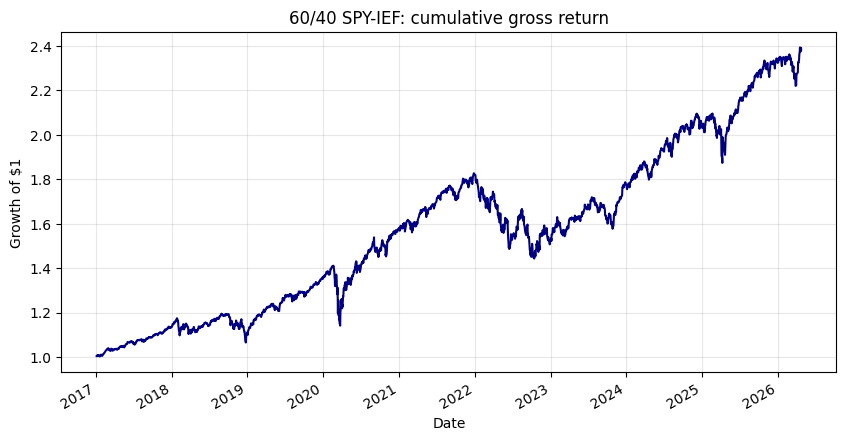

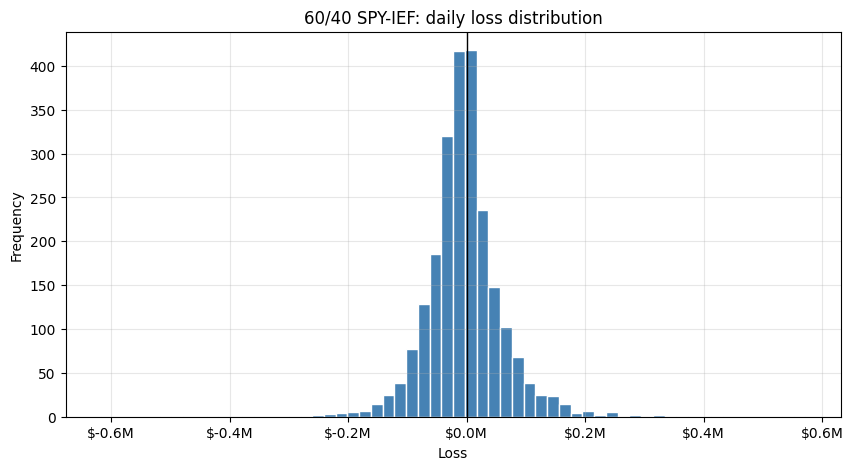

In [ ]:
fig, ax = plt.subplots()
(1 + portfolio_returns).cumprod().plot(ax=ax, color="navy")
ax.set_title(f"{PORTFOLIO_NAME}: cumulative gross return")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots()
losses.hist(bins=60, ax=ax, color="steelblue", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title(f"{PORTFOLIO_NAME}: daily loss distribution")
ax.set_xlabel("Loss")
ax.set_ylabel("Frequency")
ax.xaxis.set_major_formatter(FuncFormatter(dollars_millions))
ax.grid(True, alpha=0.3)
plt.show()

## 2. VaR and Expected Shortfall: the idea

For a confidence level $c$, the tail probability is $\alpha = 1-c$.

- At 95% confidence, the tail probability is 5%.
- At 99% confidence, the tail probability is 1%.

VaR is the loss threshold at the chosen confidence level:

$$
\mathrm{VaR}_c = Q_c(L).
$$

Expected Shortfall is the average loss once we are in the tail beyond VaR:

$$
\mathrm{ES}_c = \mathbb{E}[L \mid L \geq \mathrm{VaR}_c].
$$

VaR tells us where the tail begins. ES tells us how severe losses are once we are in that tail. When both are reported as positive losses, ES is usually larger than VaR.

## 3. Historical VaR and Historical ES

Historical VaR and ES use the empirical distribution of historical portfolio losses.

Historical VaR is the empirical high-loss quantile. Historical ES is the average of the historical loss observations in the tail beyond that VaR cutoff. In code, we use `losses >= VaR` to identify the empirical tail. Software quantile functions may interpolate between observations, but that is not the main teaching point here.

In [ ]:
window_losses = losses.iloc[-WINDOW:]


def historical_var(losses, confidence=0.99):
    """Historical VaR as a positive loss quantile."""
    return float(np.quantile(losses, confidence))


def historical_es(losses, confidence=0.99):
    """Historical ES as the average positive loss in the empirical tail beyond VaR."""
    var = historical_var(losses, confidence)
    tail_losses = losses[losses >= var]
    return float(tail_losses.mean()), int(tail_losses.shape[0])


hist_var = historical_var(window_losses, CONFIDENCE)
hist_es, hist_tail_count = historical_es(window_losses, CONFIDENCE)

historical_table = pd.DataFrame(
    {
        "Value": [hist_var, hist_es, hist_es - hist_var, hist_es / hist_var, hist_tail_count],
    },
    index=["Historical VaR", "Historical ES", "ES - VaR", "ES / VaR", "Tail observations"],
)

historical_display = pd.DataFrame(
    {
        "Value": [
            dollars(hist_var),
            dollars(hist_es),
            dollars(hist_es - hist_var),
            f"{hist_es / hist_var:.2f}x",
            f"{hist_tail_count:.0f}",
        ]
    },
    index=historical_table.index,
)
historical_display

,Value
Historical VaR,"$164,425"
Historical ES,"$252,567"
ES - VaR,"$88,141"
ES / VaR,1.54x
Tail observations,5


**Interpretation.** Historical VaR is the cutoff loss near the worst 1% of the latest 500 observations. Historical ES is the average of the losses beyond that cutoff, so it adds information about tail severity that VaR alone does not show.

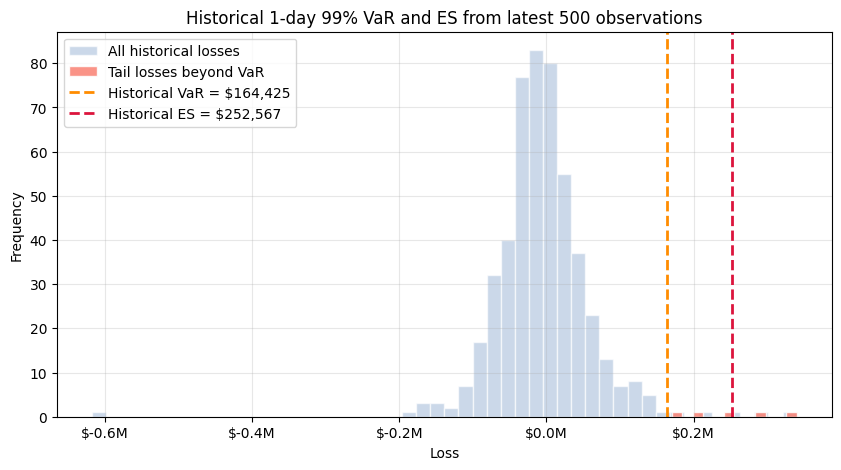

In [ ]:
fig, ax = plt.subplots()
ax.hist(window_losses, bins=50, alpha=0.65, color="lightsteelblue", edgecolor="white", label="All historical losses")
ax.hist(window_losses[window_losses >= hist_var], bins=12, alpha=0.85, color="salmon", edgecolor="white", label="Tail losses beyond VaR")
ax.axvline(hist_var, linestyle="--", linewidth=2, color="darkorange", label=f"Historical VaR = {dollars(hist_var)}")
ax.axvline(hist_es, linestyle="--", linewidth=2, color="crimson", label=f"Historical ES = {dollars(hist_es)}")
ax.set_title(f"Historical 1-day {CONFIDENCE:.0%} VaR and ES from latest {WINDOW} observations")
ax.set_xlabel("Loss")
ax.set_ylabel("Frequency")
ax.xaxis.set_major_formatter(FuncFormatter(dollars_millions))
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 4. Parametric (normal) VaR and Parametric (normal) ES

For a one-day horizon, we use the same short-horizon convention as the revised VaR lecture package:

$$
E[r_{p,t}] \approx 0.
$$

Expected daily returns are usually small relative to daily volatility, so this notebook focuses on volatility and correlation. The portfolio volatility is

$$
\sigma_p = \sqrt{w^\top \Sigma w},
$$

where $\Sigma$ is the covariance matrix of asset returns.

For confidence level $c$ and tail probability $\alpha = 1-c$:

$$
\mathrm{VaR}^{\mathrm{normal}}_c \approx V_0\sigma_p z_c,
$$

$$
\mathrm{ES}^{\mathrm{normal}}_c \approx V_0\sigma_p\frac{\varphi(z_c)}{\alpha}.
$$

Here $z_c$ is the positive standard-normal critical value and $\varphi(z_c)$ is the standard-normal density at that point.

In [ ]:
window_returns_assets = returns.iloc[-WINDOW:].loc[:, weights.index]


def portfolio_volatility(asset_returns, weights):
    """Portfolio volatility from the covariance matrix: sqrt(w' Sigma w)."""
    aligned_returns = asset_returns.loc[:, weights.index]
    cov = aligned_returns.cov().values
    w = weights.to_numpy()
    return float(np.sqrt(w @ cov @ w))


def parametric_normal_var_es(asset_returns, weights, confidence=0.99, v0=1.0):
    """Parametric (normal) VaR and ES using zero-mean daily returns."""
    sigma_p = portfolio_volatility(asset_returns, weights)
    tail_probability = 1 - confidence
    z = norm.ppf(confidence)
    var = v0 * sigma_p * z
    es = v0 * sigma_p * norm.pdf(z) / tail_probability
    return float(var), float(es), float(sigma_p)


par_var, par_es, sigma_p = parametric_normal_var_es(window_returns_assets, weights, CONFIDENCE, V0)

comparison = pd.DataFrame(
    {
        "VaR": [hist_var, par_var],
        "ES": [hist_es, par_es],
    },
    index=["Historical", "Parametric (normal)"],
)
comparison["ES - VaR"] = comparison["ES"] - comparison["VaR"]
comparison["ES / VaR"] = comparison["ES"] / comparison["VaR"]

comparison_display = pd.DataFrame(index=comparison.index)
for col in ["VaR", "ES", "ES - VaR"]:
    comparison_display[col] = comparison[col].map(dollars)
comparison_display["ES / VaR"] = comparison["ES / VaR"].map(lambda x: f"{x:.2f}x")

print(f"Daily portfolio volatility from latest {WINDOW} observations: {sigma_p:.2%}")
comparison_display

Daily portfolio volatility from latest 500 observations: 0.65%


,VaR,ES,ES - VaR,ES / VaR
Historical,"$164,425","$252,567","$88,141",1.54x
Parametric (normal),"$150,876","$172,853","$21,977",1.15x


**Interpretation.** ES is larger than VaR because it averages losses after the VaR cutoff has already been crossed. Historical ES depends on the realized tail observations in the sample. Parametric (normal) ES depends on the normal model and the estimated covariance matrix. ES gives more tail-severity information than VaR, but it does not eliminate model risk.

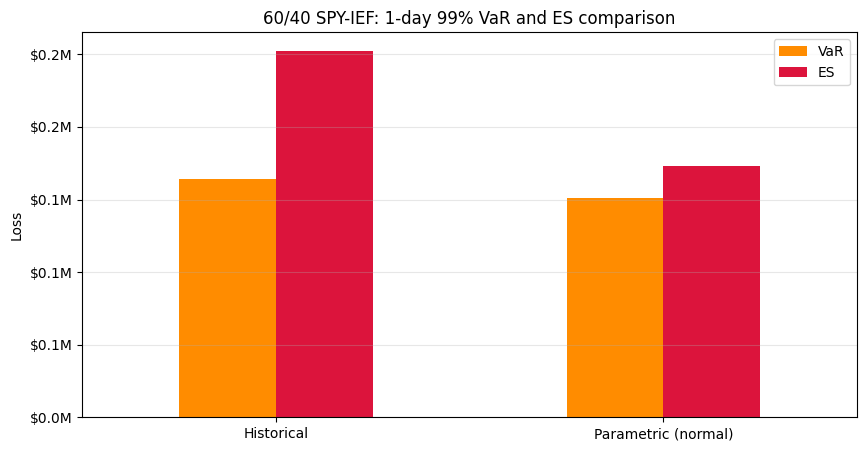

In [ ]:
fig, ax = plt.subplots()
comparison[["VaR", "ES"]].plot(kind="bar", ax=ax, color=["darkorange", "crimson"])
ax.set_title(f"{PORTFOLIO_NAME}: 1-day {CONFIDENCE:.0%} VaR and ES comparison")
ax.set_ylabel("Loss")
ax.yaxis.set_major_formatter(FuncFormatter(dollars_millions))
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
ax.grid(True, axis="y", alpha=0.3)
plt.show()

## 5. Rolling historical VaR and ES

For each test day $t$, estimate VaR and ES using the previous `WINDOW` historical losses. Then compare the realized loss on day $t$ with the VaR estimate for that day.

The rolling ES forecast is still an average tail-loss estimate. It is not a promise that every individual exception will be close to ES.

In [ ]:
def rolling_historical_var_es(losses, confidence, window, backtest_days):
    if len(losses) < window + backtest_days:
        raise ValueError("Not enough observations for the chosen estimation window and backtest length.")

    rows = []
    start_idx = len(losses) - backtest_days

    for t in range(start_idx, len(losses)):
        estimation_window = losses.iloc[t - window:t]
        realized_loss = losses.iloc[t]

        var_t = historical_var(estimation_window, confidence)
        es_t, tail_count = historical_es(estimation_window, confidence)

        rows.append(
            {
                "date": losses.index[t],
                "realized_loss": realized_loss,
                "Historical VaR": var_t,
                "Historical ES": es_t,
                "Tail observations": tail_count,
                "VaR_exception": realized_loss > var_t,
            }
        )

    return pd.DataFrame(rows).set_index("date")


bt = rolling_historical_var_es(losses, CONFIDENCE, WINDOW, BACKTEST_DAYS)
bt.head()

,realized_loss,Historical VaR,Historical ES,Tail observations,VaR_exception
date,,,,,
2025-04-25,"-58,533.7445","164,425.4323","252,566.7799",5,False
2025-04-28,"-18,252.3632","164,425.4323","252,566.7799",5,False
2025-04-29,"-51,605.3490","164,425.4323","252,566.7799",5,False
2025-04-30,"-8,635.9379","164,425.4323","252,566.7799",5,False
2025-05-01,"-25,102.6477","164,425.4323","252,566.7799",5,False


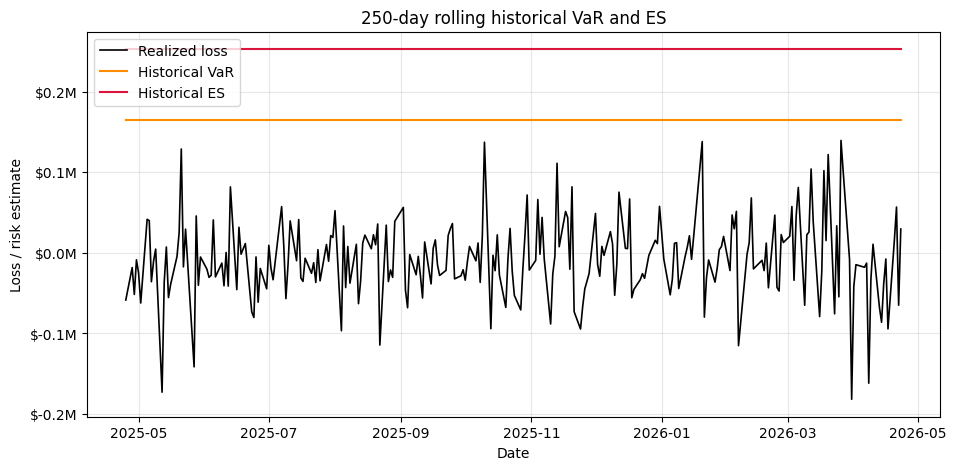

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(bt.index, bt["realized_loss"], color="black", linewidth=1.2, label="Realized loss")
ax.plot(bt.index, bt["Historical VaR"], color="darkorange", linewidth=1.5, label="Historical VaR")
ax.plot(bt.index, bt["Historical ES"], color="crimson", linewidth=1.5, label="Historical ES")
ax.set_title(f"{BACKTEST_DAYS}-day rolling historical VaR and ES")
ax.set_ylabel("Loss / risk estimate")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(FuncFormatter(dollars_millions))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.show()

## 6. What happens on VaR exception days?

A VaR exception occurs when the realized loss is larger than the VaR estimate:

$$
L_t > \widehat{\mathrm{VaR}}_{c,t}.
$$

Exception-day averages can help illustrate the tail, but they are not reliable when there are only a few exceptions. ES estimates an average tail loss, not the exact loss on any one exception day.

In [ ]:
exception_days = bt["VaR_exception"]
exception_count = int(exception_days.sum())
expected_exceptions = BACKTEST_DAYS * TAIL_PROBABILITY

if exception_count == 0:
    interpretation = "No VaR exceptions occurred, so realized exception-day averages are not available."
elif exception_count == 1:
    interpretation = "Only one VaR exception occurred; treat exception-day averages as anecdotal, not a reliable average."
else:
    interpretation = "There are multiple exceptions; averages are still sample-specific but more informative than a single event."

summary_rows = [
    ("VaR exceptions", f"{exception_count}"),
    ("Expected exceptions", f"{expected_exceptions:.1f}"),
    ("Average ES - VaR", dollars((bt["Historical ES"] - bt["Historical VaR"]).mean())),
    ("Interpretation", interpretation),
]

if exception_count > 0:
    summary_rows.extend(
        [
            ("Average realized loss on exception days", dollars(bt.loc[exception_days, "realized_loss"].mean())),
            ("Average VaR on exception days", dollars(bt.loc[exception_days, "Historical VaR"].mean())),
            ("Average ES on exception days", dollars(bt.loc[exception_days, "Historical ES"].mean())),
        ]
    )
else:
    summary_rows.extend(
        [
            ("Average realized loss on exception days", "n/a"),
            ("Average VaR on exception days", "n/a"),
            ("Average ES on exception days", "n/a"),
        ]
    )

exception_summary = pd.DataFrame(summary_rows, columns=["Metric", "Value"]).set_index("Metric")
exception_summary

,Value
Metric,
VaR exceptions,0
Expected exceptions,2.5
Average ES - VaR,"$88,141"
Interpretation,"No VaR exceptions occurred, so realized except..."
Average realized loss on exception days,n/a
Average VaR on exception days,n/a
Average ES on exception days,n/a


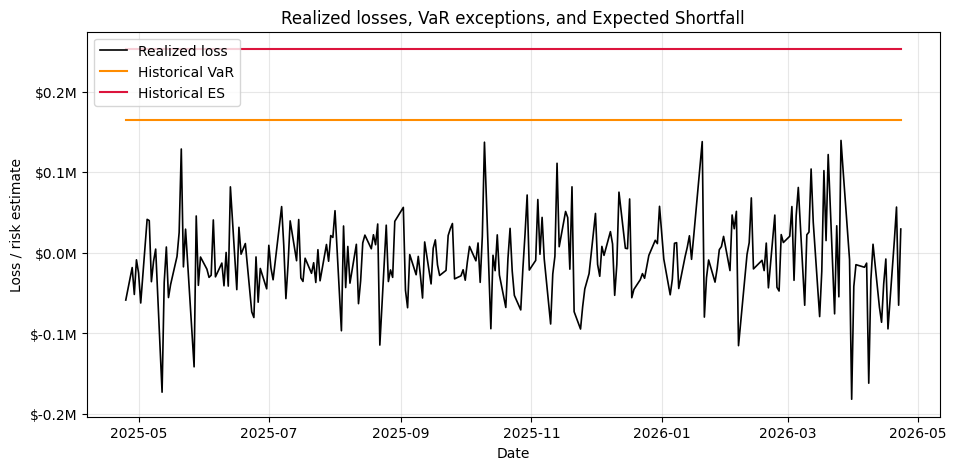

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(bt.index, bt["realized_loss"], color="black", linewidth=1.2, label="Realized loss")
ax.plot(bt.index, bt["Historical VaR"], color="darkorange", linewidth=1.5, label="Historical VaR")
ax.plot(bt.index, bt["Historical ES"], color="crimson", linewidth=1.5, label="Historical ES")

exception_dates = bt.index[bt["VaR_exception"]]
exception_losses = bt.loc[exception_dates, "realized_loss"]
if len(exception_dates) > 0:
    ax.scatter(exception_dates, exception_losses, color="red", zorder=5, label="VaR exceptions")

ax.set_title("Realized losses, VaR exceptions, and Expected Shortfall")
ax.set_ylabel("Loss / risk estimate")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(FuncFormatter(dollars_millions))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.show()

## 7. Short discussion

- By how much does ES exceed VaR?
- Which method gives the wider ES-minus-VaR gap: historical or parametric normal?
- Does ES help explain tail severity better than VaR alone?
- How much trust should we place in exception-day averages when there are few exceptions?
- What would change if the portfolio weights, confidence level, or sample period changed?